1. Import Library

In [471]:
import wfdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import biosppy.signals.ecg as ecg
from numpy.fft import fft
from scipy import signal
from hrvanalysis import get_time_domain_features, get_frequency_domain_features

In [472]:
#style settings
sns.set(style='whitegrid', rc={'axes.facecolor': '#EFF2F7'})

2. Convert File ECG to CSV

In [473]:
#Frekuensi Sampling
sampling_freq = 500

In [474]:
#Sample Frequency for ECG Sensor
settings = {}
settings['fs'] = 500

In [475]:
#Data Aritmia
recordA = wfdb.rdsamp('ARR_01')
dfA = pd.DataFrame(recordA[0], columns = recordA[1]['sig_name'])
dfA.to_csv("D:/Kuliah/Semester 6/Sistem Biomedis/Tugas Besar/Aritmia.csv", index = False)

In [476]:
#Data Normal
recordN = wfdb.rdsamp('NR_10')
dfN = pd.DataFrame(recordN[0], columns = recordN[1]['sig_name'])
dfN.to_csv("D:/Kuliah/Semester 6/Sistem Biomedis/Tugas Besar/Normal.csv", index = False)

3. Load and Plotting Data

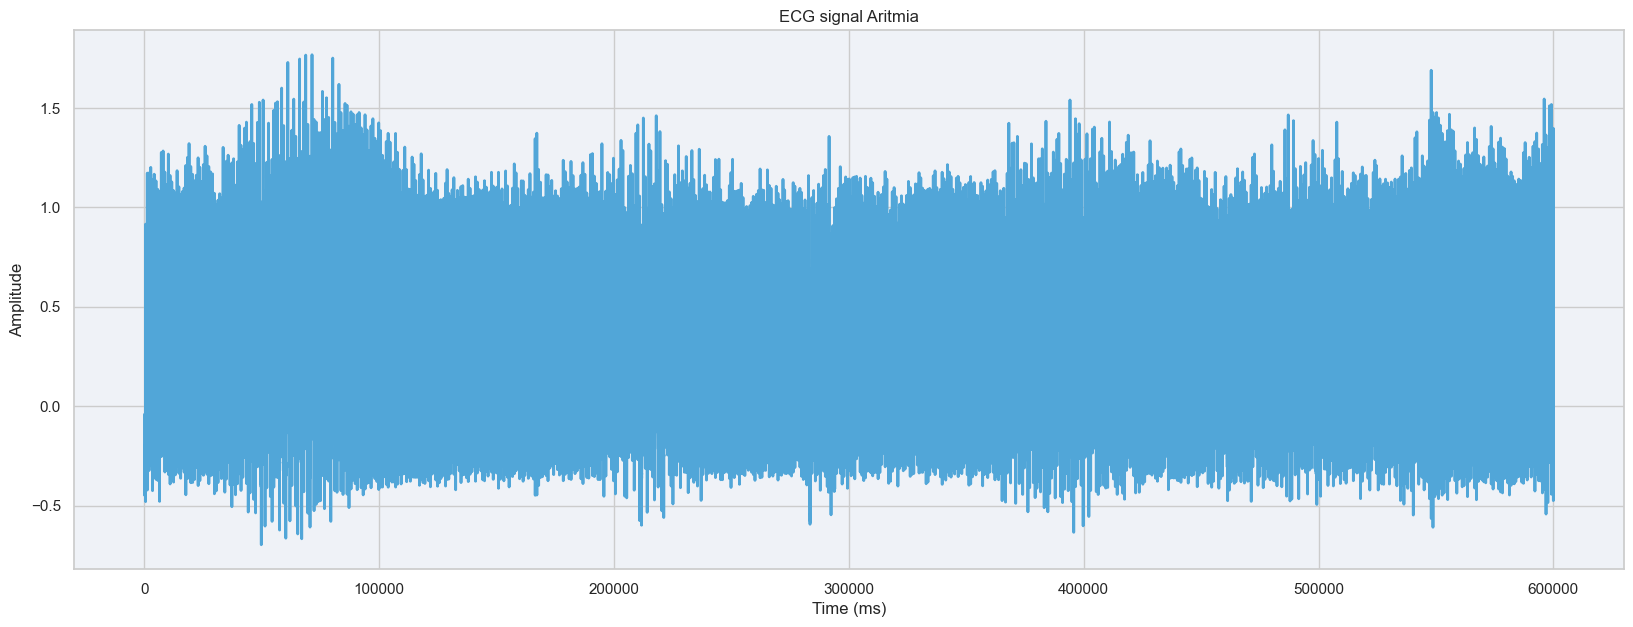

In [477]:
#Plot Data Aritmia Full
plt.figure(figsize=(20, 7))
start = 0
stop = 10000
duration = (stop-start) / settings['fs']
plt.title("ECG signal Aritmia")
plt.plot(dfA.index, dfA.ECG, color="#51A6D8", linewidth=2)
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude")
plt.show()

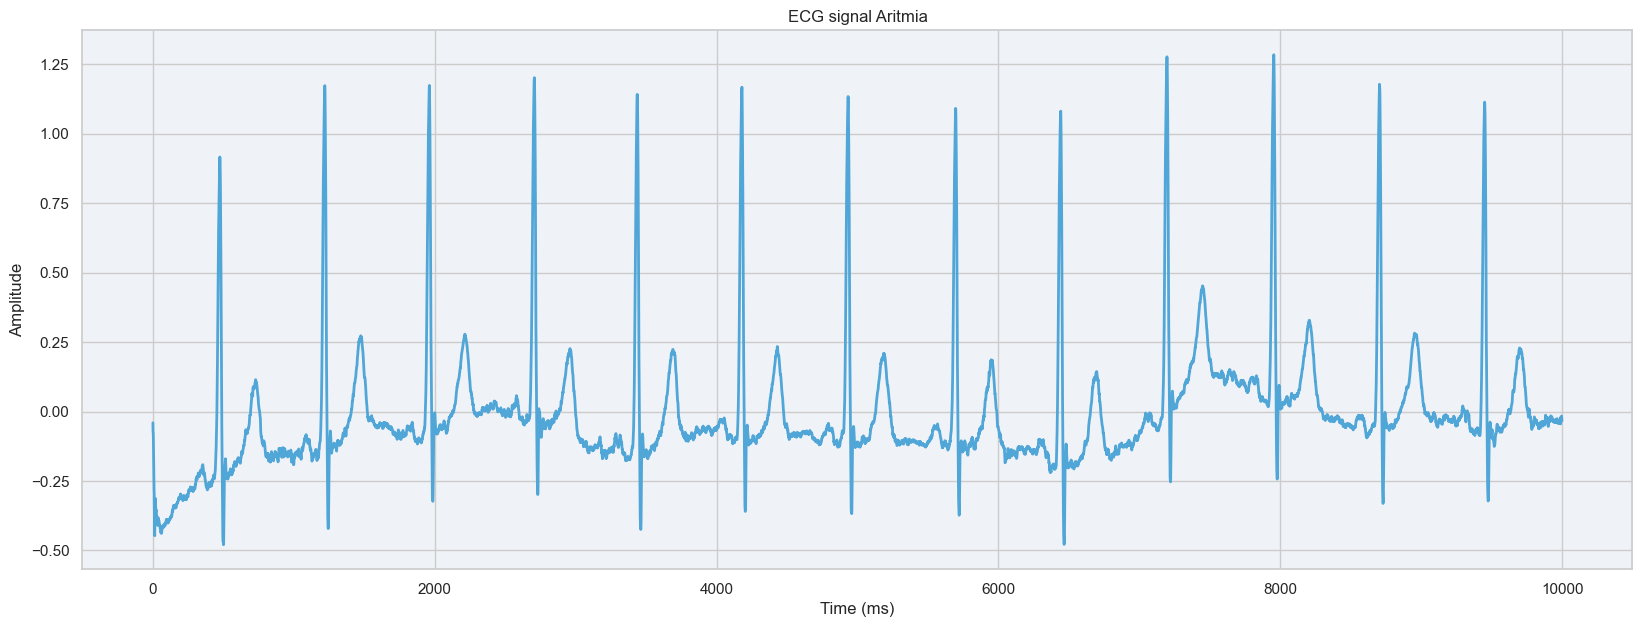

In [478]:
#Plot Data Aritmia 10 Detik
plt.figure(figsize=(20, 7))
start = 0
stop = 10000
duration = (stop-start) / settings['fs']
plt.title("ECG signal Aritmia")
plt.plot(dfA[start:stop].index, dfA[start:stop].ECG, color="#51A6D8", linewidth=2)
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude")
plt.show()

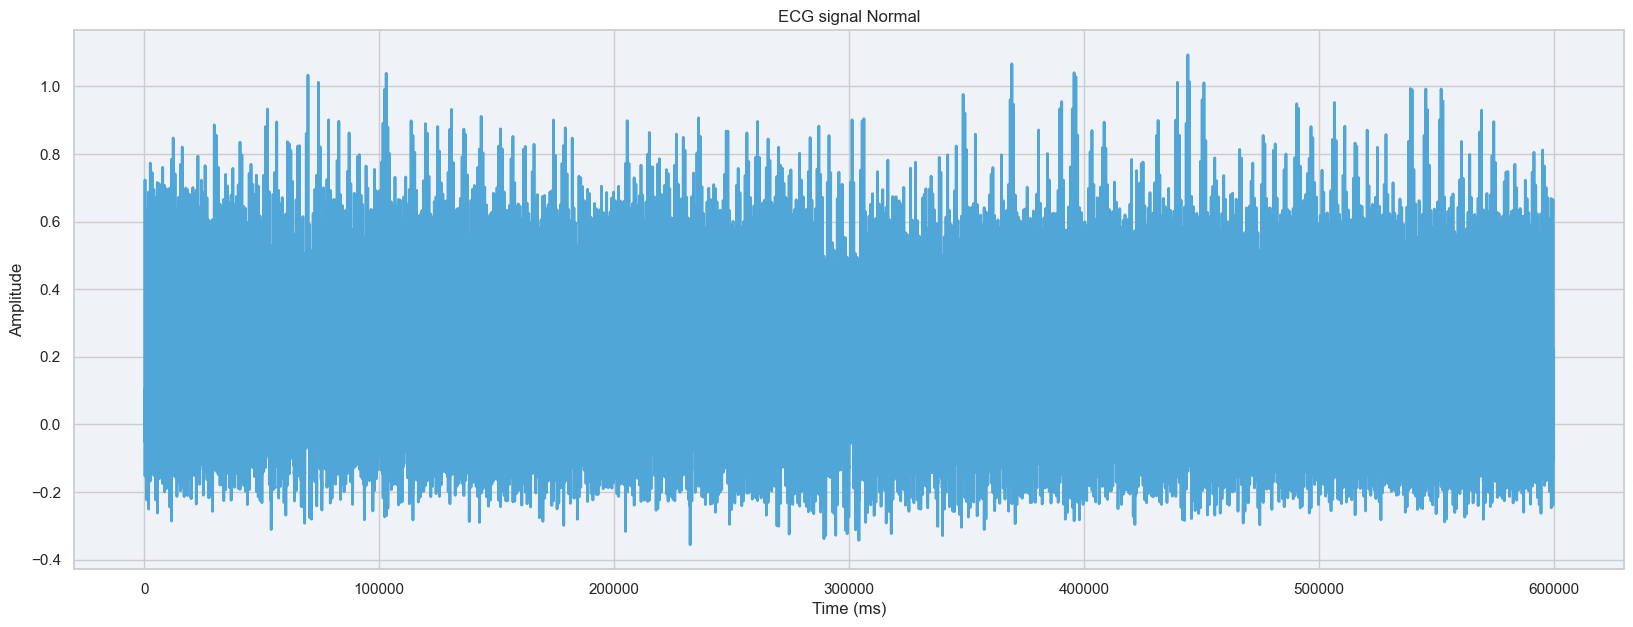

In [479]:
#Plot Data Normal Full
plt.figure(figsize=(20, 7))
start = 0
stop = 10000
duration = (stop-start) / settings['fs']
plt.title("ECG signal Normal")
plt.plot(dfN.index, dfN.ECG, color="#51A6D8", linewidth=2)
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude")
plt.show()

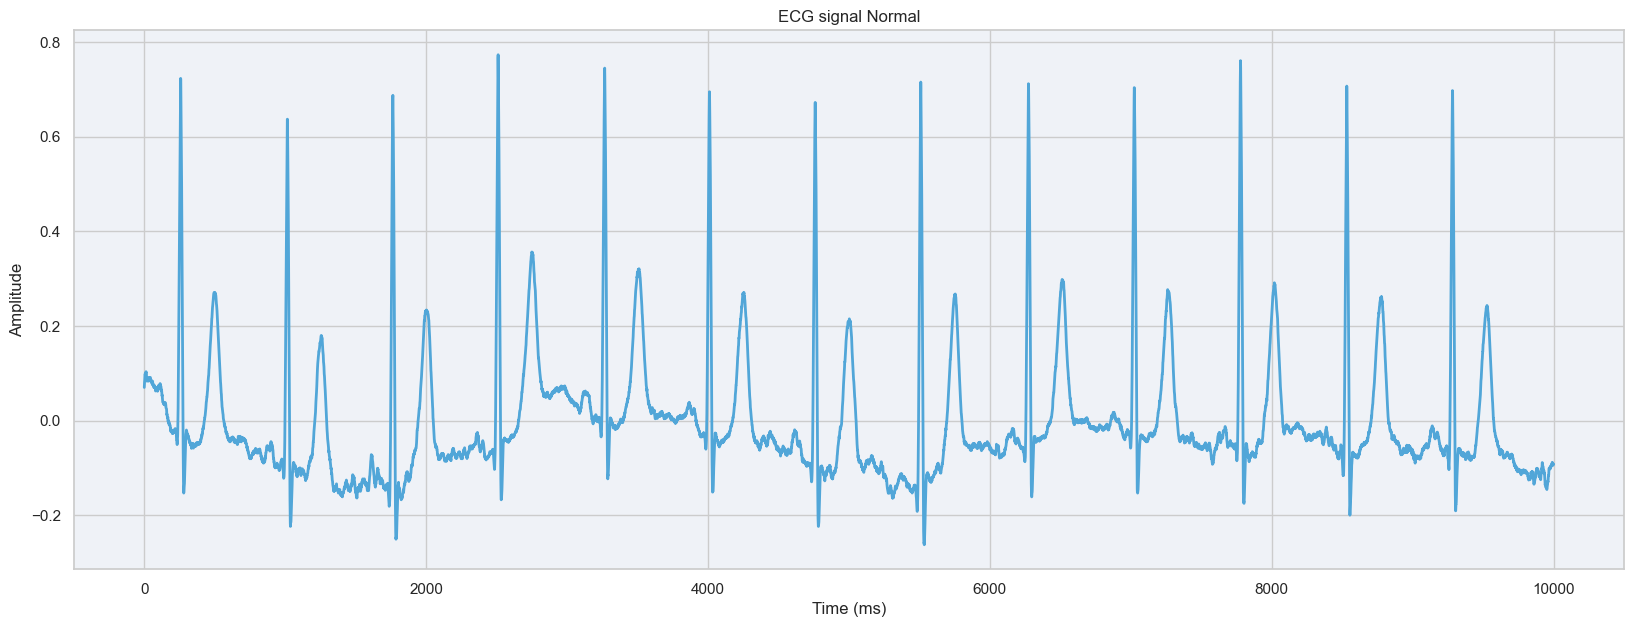

In [480]:
#Plot Data Normal 10 Detik
plt.figure(figsize=(20, 7))
start = 0
stop = 10000
duration = (stop-start) / settings['fs']
plt.title("ECG signal Normal")
plt.plot(dfN[start:stop].index, dfN[start:stop].ECG, color="#51A6D8", linewidth=2)
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude")
plt.show()

4. RR Interval

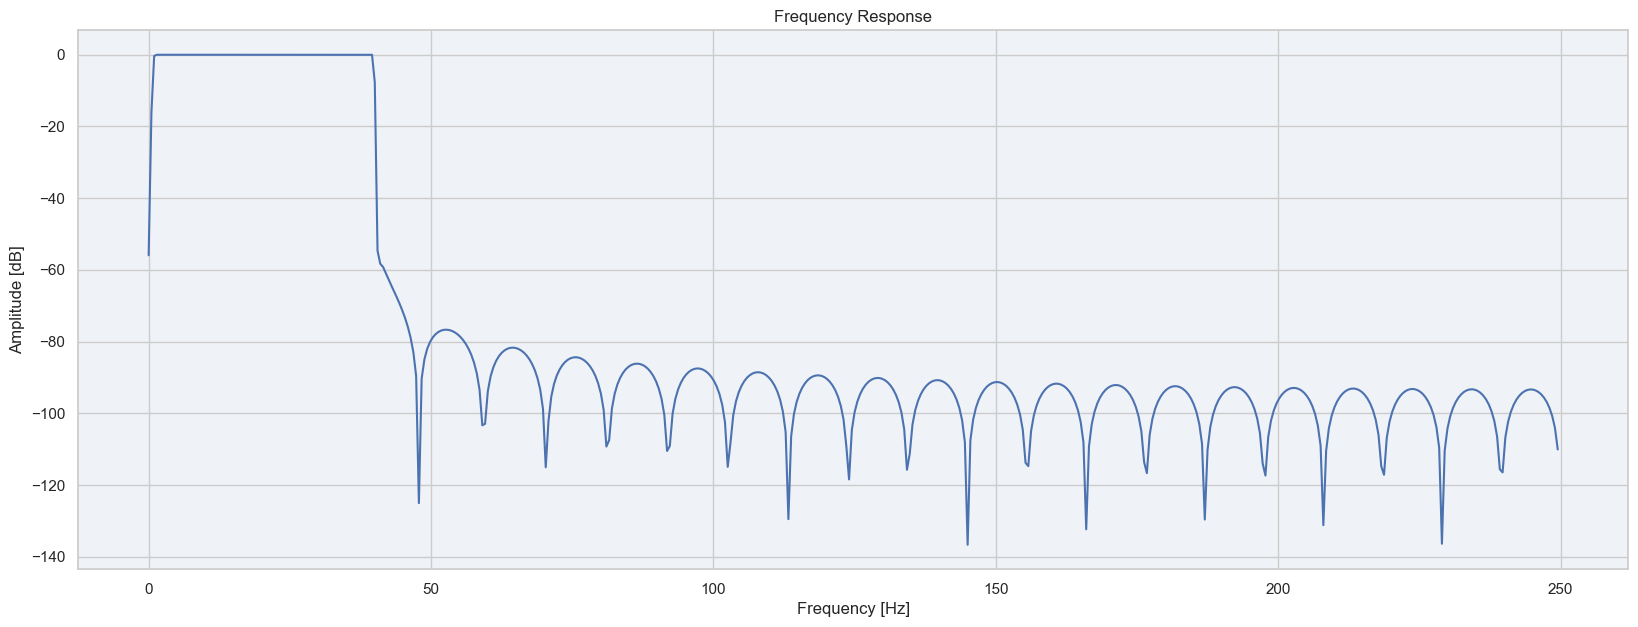

In [481]:
#Desain Filter EKG (FIRWIN, 2000 Taps, f1 0.67, f2 40)
filter = signal.firwin(2000, [0.67, 40], pass_zero=False, fs=sampling_freq)
w, h = signal.freqz(filter, fs=sampling_freq)
plt.figure(figsize=(20, 7))
plt.plot(w, 20*np.log10(abs(h)), 'b')
plt.title('Frequency Response')
plt.ylabel('Amplitude [dB]')
plt.xlabel('Frequency [Hz]')
plt.show()

Text(0, 0.5, 'Amplitude')

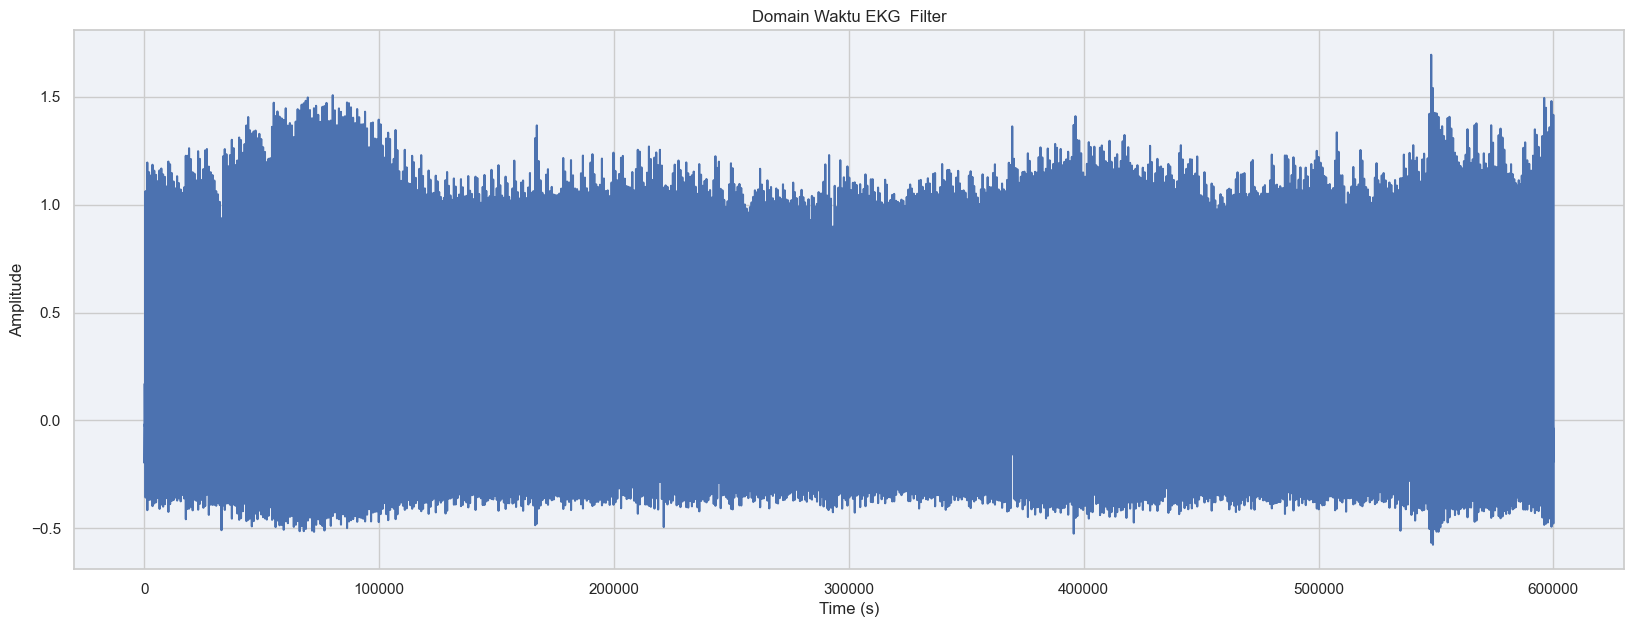

In [482]:
#Filterisasi Data Aritmia
aritmia = dfA.ECG
ekg_filter_aritmia = signal.convolve(aritmia, filter, mode = 'same')

plt.figure(figsize=(20, 7))
plt.title('Domain Waktu EKG  Filter')
plt.plot(dfA.index, ekg_filter_aritmia)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')


In [483]:
#RR Interval Aritmia
out_aritmia = ecg.ecg(signal=ekg_filter_aritmia, sampling_rate=sampling_freq, show=False) 
rpeaks_aritmia = out_aritmia["rpeaks"]

rr_intervals_aritmia = np.diff(out_aritmia['rpeaks']) / sampling_freq

Text(0, 0.5, 'Amplitude')

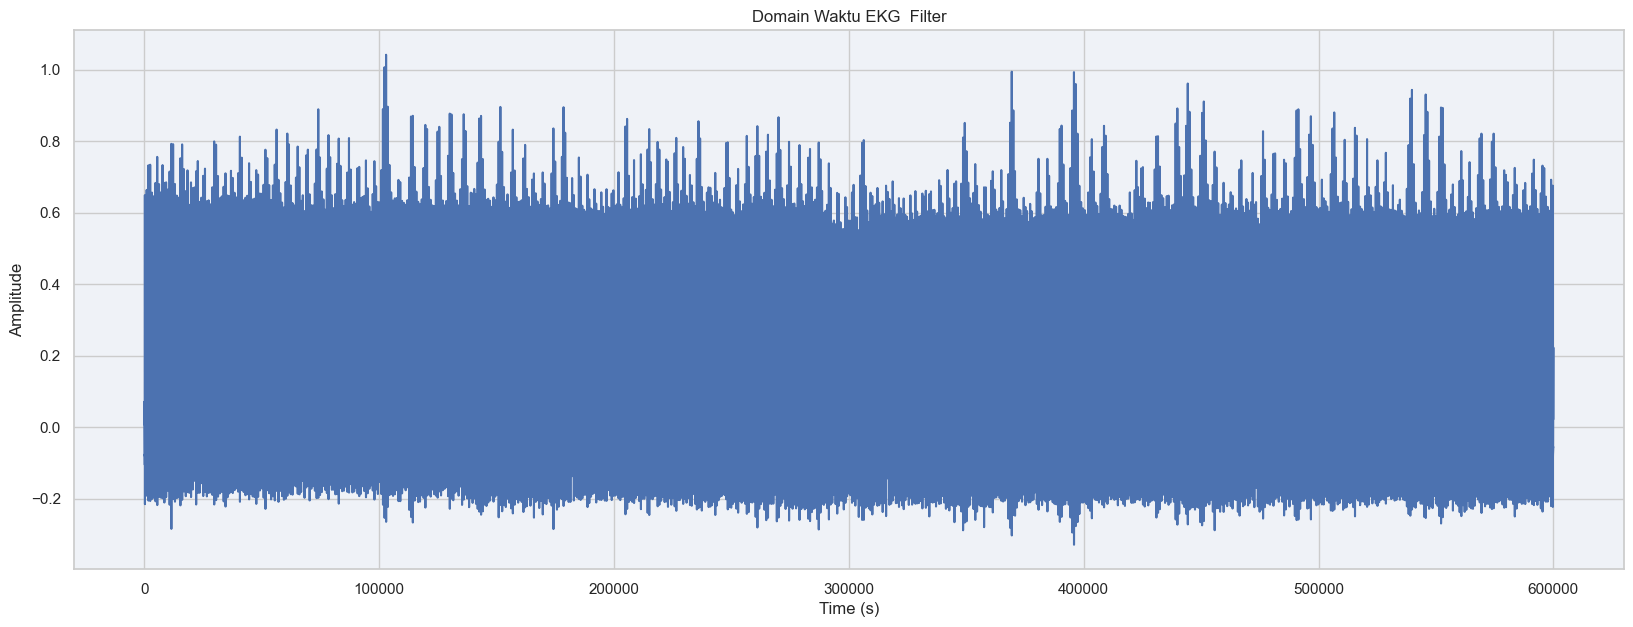

In [484]:
#Filterisasi Data Normal
normal = dfN.ECG
ekg_filter_normal = signal.convolve(normal, filter, mode = 'same')

plt.figure(figsize=(20, 7))
plt.title('Domain Waktu EKG  Filter')
plt.plot(dfN.index, ekg_filter_normal)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')

In [485]:
#RR Interval Aritmia
out_normal = ecg.ecg(signal=ekg_filter_normal, sampling_rate=sampling_freq, show=False) 
rpeaks_normal = out_normal["rpeaks"]

rr_intervals_normal = np.diff(out_normal['rpeaks']) / sampling_freq

5. HRV Analysis

In [486]:
#Time Domain Analysis Aritmia
time_domain_features = get_time_domain_features(rr_intervals_aritmia)
print(time_domain_features)

#Frequency Domain Analysis Aritmia
freq_domain_features = get_frequency_domain_features(rr_intervals_aritmia)
print(freq_domain_features)

{'mean_nni': 1.5410321750321752, 'sdnn': 0.08476225237303908, 'sdsd': 0.0359788925615916, 'nni_50': 0, 'pnni_50': 0.0, 'nni_20': 0, 'pnni_20': 0.0, 'rmssd': 0.03597894573333792, 'median_nni': 1.538, 'range_nni': 0.5800000000000001, 'cvsd': 0.023347303395911716, 'cvnni': 0.05500355784023091, 'mean_hr': 39051.29697298353, 'max_hr': 46728.97196261682, 'min_hr': 32188.841201716736, 'std_hr': 2126.434404867863}
{'lf': 7.900088588165523e-05, 'hf': 0.00038317814527646845, 'lf_hf_ratio': 0.20617273415908147, 'lfnu': 17.093135031179497, 'hfnu': 82.9068649688205, 'total_power': 0.00048319025351251744, 'vlf': 2.1011222354393743e-05}


In [487]:
#Time Domain Analysis Aritmia
time_domain_features2 = get_time_domain_features(rr_intervals_normal)
print(time_domain_features2)

#Frequency Domain Analysis Aritmia
freq_domain_features2 = get_frequency_domain_features(rr_intervals_normal)
print(freq_domain_features2)

{'mean_nni': 1.4747527675276755, 'sdnn': 0.05266544779988016, 'sdsd': 0.02805858779932859, 'nni_50': 0, 'pnni_50': 0.0, 'nni_20': 0, 'pnni_20': 0.0, 'rmssd': 0.02805878768768287, 'median_nni': 1.48, 'range_nni': 0.34799999999999986, 'cvsd': 0.019026095970459886, 'cvnni': 0.03571137410928224, 'mean_hr': 40737.517879328894, 'max_hr': 46656.29860031104, 'min_hr': 36719.70624235006, 'std_hr': 1480.2649477870045}
{'lf': 9.381175220589524e-05, 'hf': 0.00021793082693228705, 'lf_hf_ratio': 0.43046572862793453, 'lfnu': 30.0926977845758, 'hfnu': 69.90730221542421, 'total_power': 0.000341818326191949, 'vlf': 3.007574705376672e-05}
